解压并展示数据：

In [2]:
import os
import tarfile

import numpy as np
import pandas as pd
from IPython.core.display import display_svg
from pandas.core.array_algos.replace import should_use_regex
from tensorboard.notebook import display

# 设定路径
HOUSING_PATH = os.path.join("datasets", "housing")
tgz_path = os.path.join(HOUSING_PATH, "housing.tgz")
csv_path = os.path.join(HOUSING_PATH, "housing.csv")

# 1. 解压手动放入的完整压缩包
if os.path.isfile(tgz_path):
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=HOUSING_PATH)
    print("解压成功！housing.csv 已生成。")

# 2. 加载并查看前 5 行数据
housing = pd.read_csv(csv_path)
housing.head()

解压成功！housing.csv 已生成。


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


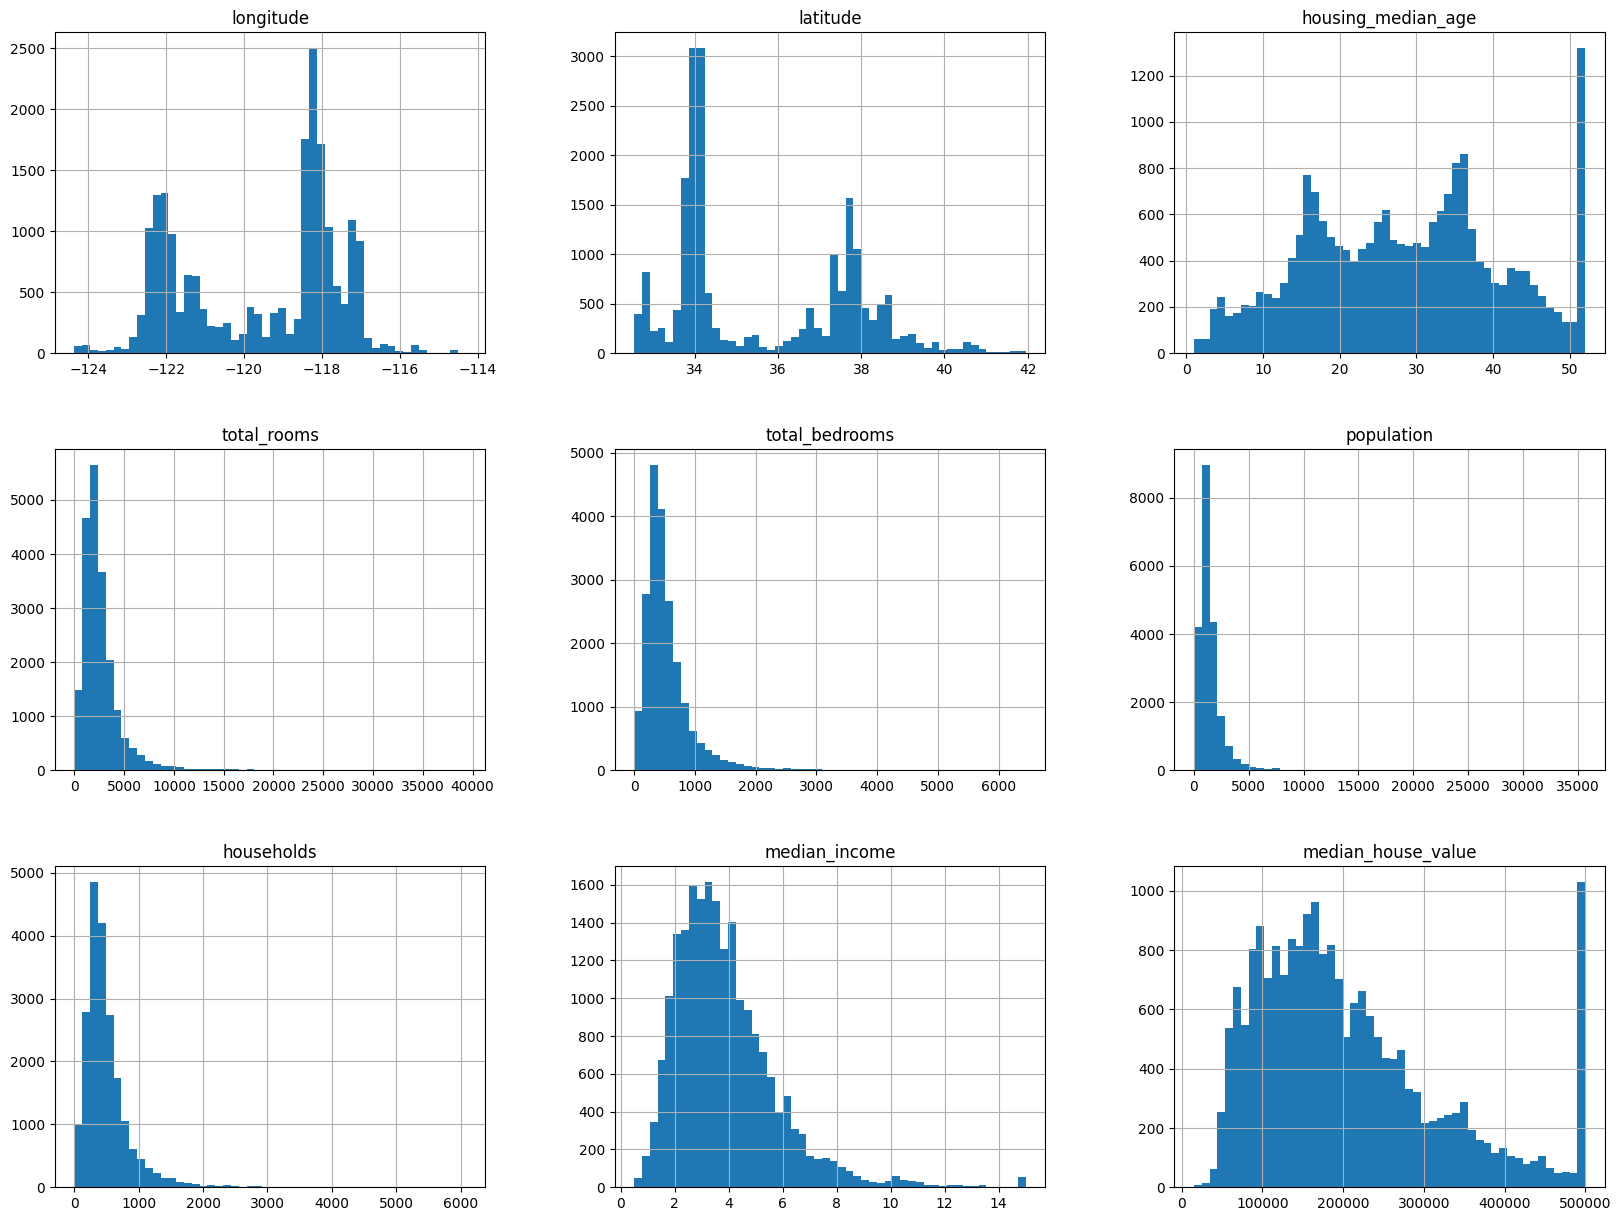

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20, 15))
plt.show()

创建测试集：

In [7]:
from sklearn.model_selection import train_test_split
train_set,test_set = train_test_split(housing, test_size=0.2, random_state=42)

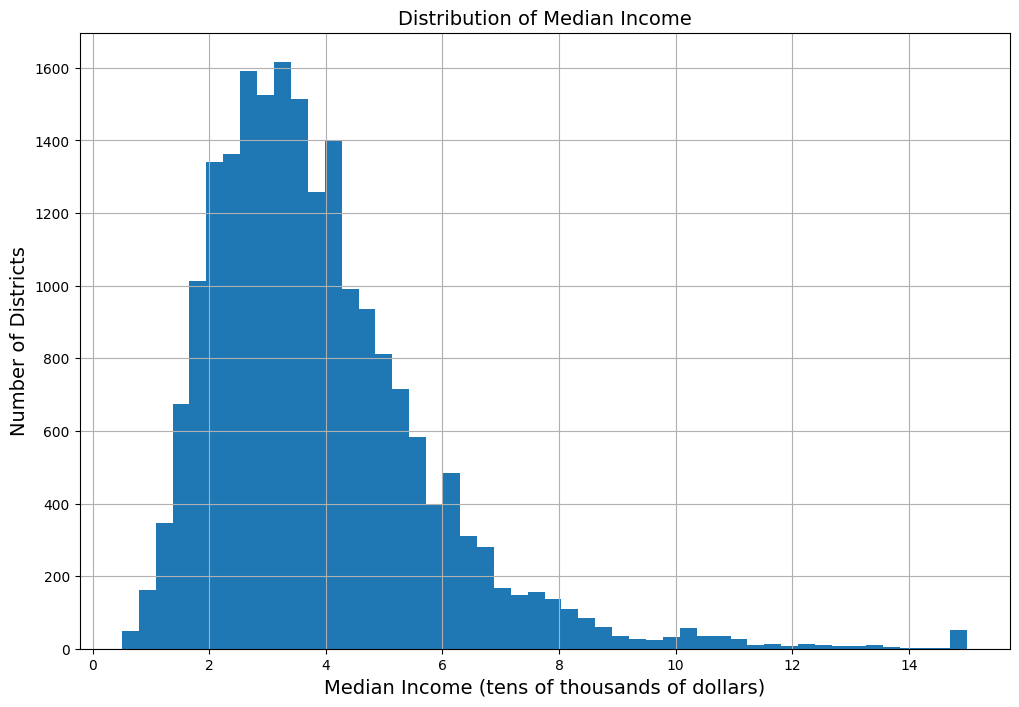

In [8]:
import matplotlib.pyplot as plt

# 设置绘图风格（可选，让图表更美观）
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# 绘制收入中位数的直方图
housing["median_income"].hist(bins=50, figsize=(12, 8))
plt.xlabel("Median Income (tens of thousands of dollars)")
plt.ylabel("Number of Districts")
plt.title("Distribution of Median Income")
plt.show()

In [13]:
import numpy as np
housing['income_cat'] = np.ceil(housing['median_income'] / 1.5)
housing['income_cat'].where(housing['income_cat'] < 5, 5.0, inplace=True)

C:\Users\24677\AppData\Local\Temp\ipykernel_38116\4051340918.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['income_cat'].where(housing['income_cat'] < 5, 5.0, inplace=True)


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1,test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]


In [15]:
housing['income_cat'].value_counts()/len(housing)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

删除income_cat:

In [16]:
for set in (strat_train_set, strat_test_set):
    set.drop(['income_cat'], axis=1, inplace=True)

数据探索和数据可视化：

In [17]:
housing = strat_train_set.copy()

数据的地理分布图：

<Axes: xlabel='longitude', ylabel='latitude'>

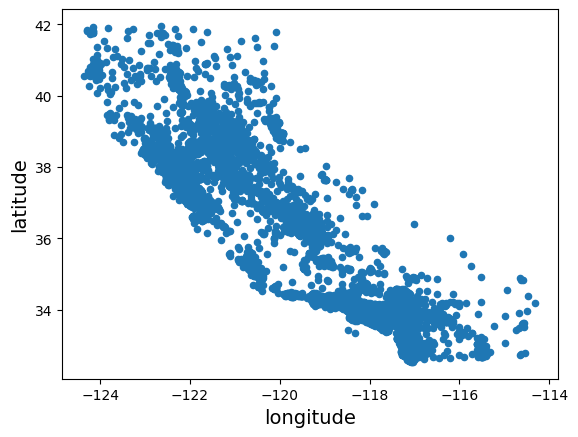

In [21]:
housing.plot(kind='scatter', x='longitude', y='latitude')

突出高密度区域的可视化:

<Axes: xlabel='longitude', ylabel='latitude'>

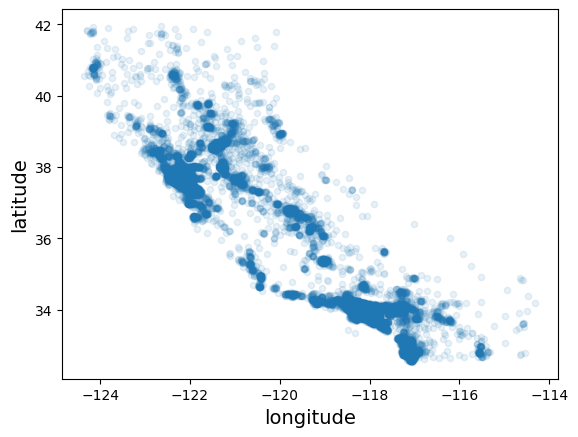

In [22]:
housing.plot(kind ='scatter', x='longitude', y='latitude',alpha = 0.1)

加利福尼亚州房屋价格：

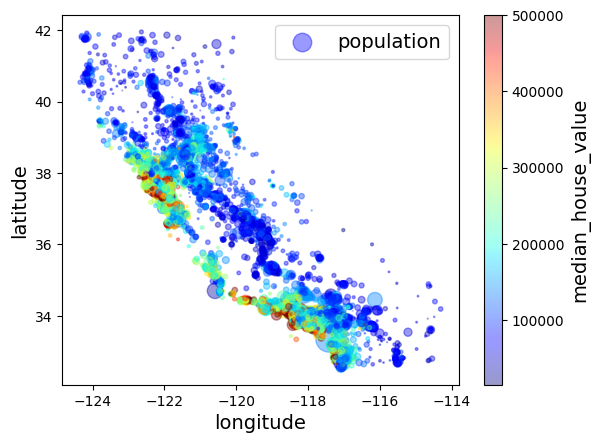

In [23]:
housing.plot(kind='scatter',
             x='longitude',
             y='latitude',
             alpha = 0.4,
             s = housing['population']/100,
             label = 'population',
             c= 'median_house_value',
             cmap = plt.get_cmap('jet'),
             colorbar = True
             )
plt.legend()

寻找相关性：

In [25]:
# 自动选择所有整数和浮点数类型的列
corr_matrix = housing.select_dtypes(include=['int64', 'float64']).corr()

In [26]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

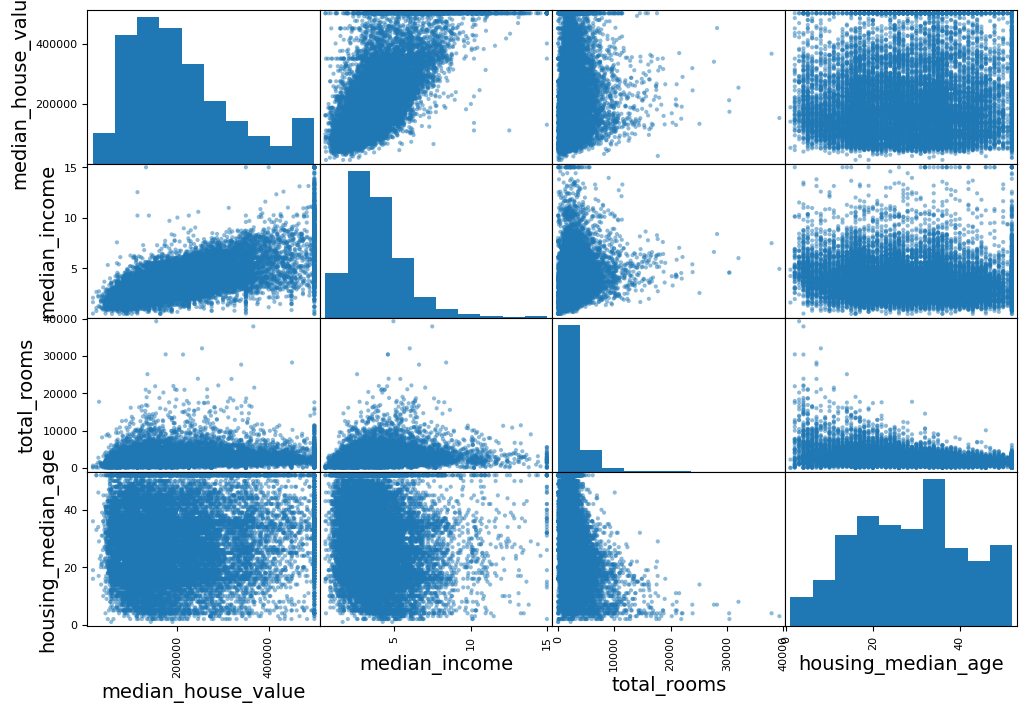

In [27]:
from pandas.plotting import scatter_matrix
attributes = ['median_house_value','median_income','total_rooms','housing_median_age']
scatter_matrix(housing[attributes], figsize=(12,8))


<Axes: xlabel='median_income', ylabel='median_house_value'>

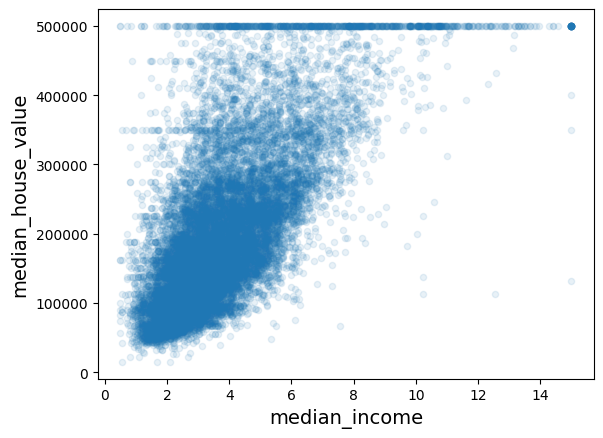

In [28]:
housing.plot(kind='scatter',x= 'median_income',y='median_house_value',alpha = 0.1)

试验不同属性的组合：

In [31]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household'] = housing['population']/housing['households']

关联矩阵：

In [33]:
corr_matrix = housing.select_dtypes(include=['int64', 'float64']).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

机器学习的算法准备：

In [34]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

替换缺失值：

In [35]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')


舍弃文本属性：

In [36]:
housing_num = housing.drop('ocean_proximity', axis=1)

将imputer适配到训练集：

In [37]:
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [38]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [39]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [40]:
X = imputer.transform(housing_num)

In [41]:
housing_tr = pd.DataFrame(X,columns=housing_num.columns)

In [42]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
housing_cat  = housing['ocean_proximity']
housing_cat_encoded = encoder.fit_transform(housing_cat)
housing_cat_encoded

array([1, 4, 1, ..., 0, 0, 1], shape=(16512,))

In [43]:
print(encoder.classes_)

['<1H OCEAN' 'INLAND' 'ISLAND' 'NEAR BAY' 'NEAR OCEAN']


In [44]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
housing_cat_1hot = encoder.fit_transform(housing_cat_encoded.reshape(-1,1))
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [45]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

使用LabelBinarizer类可以一次性完成这两个转换：

In [46]:
from sklearn.preprocessing import LabelBinarizer
encoder = LabelBinarizer()
housing_cat_1hot = encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0],
       ...,
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0]], shape=(16512, 5))

自定义转换器：

In [47]:
from sklearn.base import BaseEstimator,TransformerMixin

rooms_ix,bedrooms_ix,population_ix,household_ix = 3,4,5,6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self,add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self,X,y = None):
        return self # nothing else to do
    def transform(self,X,y = None):
        rooms_per_household = X[:,rooms_ix]/X[:,household_ix]
        population_per_household = X[:,population_ix]/X[:,household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:,bedrooms_ix]/X[:,rooms_ix]
            return np.c_[X,rooms_per_household,population_per_household,bedrooms_per_room]
        else:
            return np.c_[X,rooms_per_household,population_per_household]
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

# 转换流水线：

In [57]:
from sklearn.base import BaseEstimator,TransformerMixin
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self,X,y = None):
        return self
    def transform(self,X):
        return X[self.attribute_names].values

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('one_hot_encoder', OneHotEncoder(sparse_output=False)),
])

full_pipeline = FeatureUnion(transformer_list=[
    ('num_pipeline', num_pipeline),
    ('cat_pipeline', cat_pipeline),
])

运行整条流水线：

In [66]:
housing_prepared = full_pipeline.fit_transform(housing)

In [67]:
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 16))

In [68]:
housing_prepared.shape

(16512, 16)

## 选择和训练模型：

培训和评估模型：

In [70]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


用训练集的实例测试模型的工作效果：

In [74]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print('Predictions: \t',list(lin_reg.predict(some_data_prepared)))

Predictions: 	 [np.float64(85657.90192014407), np.float64(305492.6073748765), np.float64(152056.46122455693), np.float64(186095.7094609436), np.float64(244550.6796608895)]


In [73]:
print('Labels:\t\t',list(some_labels))

Labels:		 [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


可以工作了，但是预测的还不是很准确

测量RMSE：

In [75]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

模型欠拟合

使用其他的模型：

In [76]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [77]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

严重过拟合

## 使用交叉验证来更好的进行评估

In [79]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring='neg_mean_squared_error',cv=10)
tree_rmse_scores = np.sqrt(-scores)

结果：

In [80]:
def display_scores(scores):
    print('Scores',scores)
    print('Mean:',scores.mean())
    print('Standard Deviation:',scores.std())

display_scores(tree_rmse_scores)

Scores [73298.5122866  71869.88396728 69278.89417069 72393.51296468
 71096.68280955 77393.71939314 71885.24236717 73230.30817339
 68212.52671797 71255.68069576]
Mean: 71991.49635462409
Standard Deviation: 2357.8717957369176


保守起见，线性回归的如下：

In [81]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,scoring ='neg_mean_squared_error' , cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard Deviation: 2880.3282098180666


可以发现，决策树过拟合程度比线性回归高

测试随机森林模型：

In [84]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)

forest_rmse

np.float64(18799.912976893575)

In [85]:
forest_scores = cross_val_score(forest_reg,housing_prepared, housing_labels,scoring ='neg_mean_squared_error' , cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores [51482.12899227 48596.67289307 46931.27160255 52021.14324781
 47282.18045924 51664.4378978  52530.66721873 49847.9413748
 48416.296667   53411.75208507]
Mean: 50218.44924383493
Standard Deviation: 2189.1416150872897


虽然小了很多，但是仍然还是过拟合

In [87]:
import joblib
joblib.dump(forest_reg,'my_model.pkl')
# and later...
my_model_loaded = joblib.load('my_model.pkl')

微调模型：

网格搜索：

In [89]:
from sklearn .model_selection import GridSearchCV
param_grid = [
    {'n_estimators':[3,10,30],'max_features':[2,4,6,8]},
    {'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]},
]

forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid,cv = 5,scoring='neg_mean_squared_error')
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,30


In [90]:
# 打印最佳模型的详细超参数
print("最佳模型超参数：")
print(grid_search.best_estimator_)

# 打印最佳交叉验证分数
print("\n最佳交叉验证分数（负均方误差）：", grid_search.best_score_)

# 打印最佳参数组合
print("\n最佳参数组合：", grid_search.best_params_)

最佳模型超参数：
RandomForestRegressor(max_features=8, n_estimators=30)

最佳交叉验证分数（负均方误差）： -2505966788.8075743

最佳参数组合： {'max_features': 8, 'n_estimators': 30}


得到最好的估算器：

In [91]:
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


还有评估分数：

In [92]:
cvres = grid_search.cv_results_
for mean_score,params in zip(cvres['mean_test_score'],cvres['params']):
    print(np.sqrt(-mean_score),params)

63220.309040109874 {'max_features': 2, 'n_estimators': 3}
55320.91306418881 {'max_features': 2, 'n_estimators': 10}
52613.874008208026 {'max_features': 2, 'n_estimators': 30}
60533.6827824052 {'max_features': 4, 'n_estimators': 3}
53053.16396359568 {'max_features': 4, 'n_estimators': 10}
50650.3897119024 {'max_features': 4, 'n_estimators': 30}
58562.70578424093 {'max_features': 6, 'n_estimators': 3}
52190.96441206361 {'max_features': 6, 'n_estimators': 10}
50061.91113318566 {'max_features': 6, 'n_estimators': 30}
58883.14915176527 {'max_features': 8, 'n_estimators': 3}
52515.24982810563 {'max_features': 8, 'n_estimators': 10}
50059.6323279304 {'max_features': 8, 'n_estimators': 30}
61767.18199873114 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54768.658070649384 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59716.51880555162 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52560.60605185817 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10

分析最佳模型及其错误：

In [94]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([7.04399620e-02, 6.35693872e-02, 4.44170279e-02, 1.53128228e-02,
       1.47760693e-02, 1.47468291e-02, 1.30029722e-02, 3.82053611e-01,
       4.93082112e-02, 1.11930671e-01, 6.06094023e-02, 9.74918632e-03,
       1.44614446e-01, 1.80693028e-05, 1.78751389e-03, 3.66381870e-03])

重要性分数显示在对应的属性旁边：

In [97]:
extra_attribs = ['rooms_per_hhold', 'pop_per_hhold', 'bedrooms_per_room']
cat_one_hot_attribs = list(encoder.classes_)
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.38205361101444374), 'median_income'),
 (np.float64(0.14461444594388634), np.str_('INLAND')),
 (np.float64(0.11193067092754407), 'pop_per_hhold'),
 (np.float64(0.07043996197308104), 'longitude'),
 (np.float64(0.06356938715139669), 'latitude'),
 (np.float64(0.06060940231841697), 'bedrooms_per_room'),
 (np.float64(0.049308211156979205), 'rooms_per_hhold'),
 (np.float64(0.04441702788865998), 'housing_median_age'),
 (np.float64(0.015312822794545395), 'total_rooms'),
 (np.float64(0.014776069330389786), 'total_bedrooms'),
 (np.float64(0.014746829093930967), 'population'),
 (np.float64(0.013002972193628316), 'households'),
 (np.float64(0.009749186320409893), np.str_('<1H OCEAN')),
 (np.float64(0.0036638186951679095), np.str_('NEAR OCEAN')),
 (np.float64(0.00178751389476643), np.str_('NEAR BAY')),
 (np.float64(1.8069302753340633e-05), np.str_('ISLAND'))]

通过测试集评估系统：

In [99]:
final_model = grid_search.best_estimator_

X_test  =strat_test_set.drop('median_house_value', axis=1)
y_test = strat_test_set.median_house_value.copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)